***Case study 2: Phân tích ảm xúc văn bản (sentiment analysis)***
    
• Input: data là các câu đánh giá phim (tìm trên kaggle)

• Dùng LSTM/GRU + embedding

• Sinh viên giải thích pipeline xử lý text

***Cell 1: Import libraries***

In [1]:
#B22DCCN476 - Đỗ Ngọc Lâm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


***Cell 2: Load movie review dataset***

In [2]:
#B22DCCN476 - Đỗ Ngọc Lâm


data_path = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\cuoiKi-onTap\caseStudy2\IMDB_Dataset.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


***Cell 3: Encode sentiment labels***

In [3]:
#B22DCCN476 - Đỗ Ngọc Lâm

# sentiment: positive -> 1 | negative -> 0
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

texts = df["review"].astype(str).values
labels = df["label"].astype(int).values

print(df["label"].value_counts())
df.head()


label
1    25000
0    25000
Name: count, dtype: int64


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


***Cell 4: Plot label distribution & review length histogram***

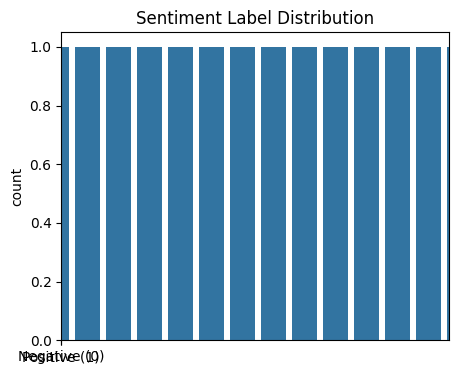

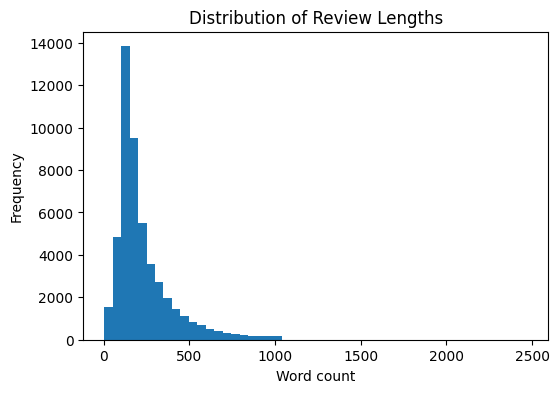

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review, dtype: float64


In [4]:
#B22DCCN476 - Đỗ Ngọc Lâm

plt.figure(figsize=(5,4))
sns.countplot(df["label"])
plt.xticks([0,1], ["Negative (0)", "Positive (1)"])
plt.title("Sentiment Label Distribution")
plt.show()

# Độ dài review (tính theo số từ)
review_lengths = df["review"].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))
plt.hist(review_lengths, bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

print(review_lengths.describe())


***Cell 5: Split dataset***

In [5]:
#B22DCCN476 - Đỗ Ngọc Lâm

X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=SEED, stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=SEED, stratify=y_temp
)

print(len(X_train), len(X_val), len(X_test))


35000 5000 10000


***Cell 6: Tokenize & pad***

In [6]:
#B22DCCN476 - Đỗ Ngọc Lâm

MAX_VOCAB = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

def pad_text(data):
    seqs = tokenizer.texts_to_sequences(data)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_seq = pad_text(X_train)
X_val_seq   = pad_text(X_val)
X_test_seq  = pad_text(X_test)

print("Train seq:", X_train_seq.shape)


Train seq: (35000, 200)


***Cell 7: Build LSTM Model***

In [7]:
#B22DCCN476 - Đỗ Ngọc Lâm

EMBED_DIM = 128

def build_lstm():
    model = models.Sequential([
        layers.Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        layers.SpatialDropout1D(0.2),
        layers.LSTM(128),
        layers.Dropout(0.5),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

lstm_model = build_lstm()
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

***Cell 8: Train LSTM***

In [9]:
#B22DCCN476 - Đỗ Ngọc Lâm


BATCH_SIZE = 128
EPOCHS = 10

history_lstm = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 61s 224ms/step - accuracy: 0.6129 - loss: 0.6476 - val_accuracy: 0.6054 - val_loss: 0.6559
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 61s 224ms/step - accuracy: 0.6711 - loss: 0.5852 - val_accuracy: 0.7014 - val_loss: 0.5756
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 62s 225ms/step - accuracy: 0.7625 - loss: 0.5025 - val_accuracy: 0.8488 - val_loss: 0.3668
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 65s 236ms/step - accuracy: 0.8909 - loss: 0.2945 - val_accuracy: 0.8636 - val_loss: 0.3381
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 66s 242ms/step - accuracy: 0.9291 - loss: 0.2124 - val_accuracy: 0.8676 - val_loss: 0.3611
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 66s 242ms/step - accuracy: 0.9483 - loss: 0.1652 - val_accuracy: 0.8656 - val_loss: 0.3900
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 66s 242ms/step - accuracy: 0.9643 - loss: 0.1262 - val_accuracy: 0.8646 - val_loss: 0.4545
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 66s 242ms/step - accuracy: 0.9693 - loss: 0

***Cell 9: Plot training curves (LSTM)***

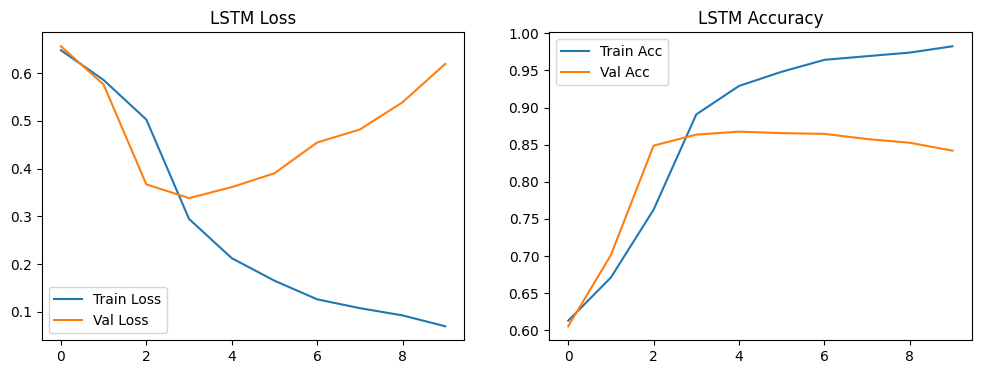

In [13]:
#B22DCCN476 - Đỗ Ngọc Lâm

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Val Loss")
plt.title("LSTM Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_lstm.history["accuracy"], label="Train Acc")
plt.plot(history_lstm.history["val_accuracy"], label="Val Acc")
plt.title("LSTM Accuracy")
plt.legend()

plt.show()


***Cell 10: Test LSTM***

0.6252360343933105 0.839900016784668
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step


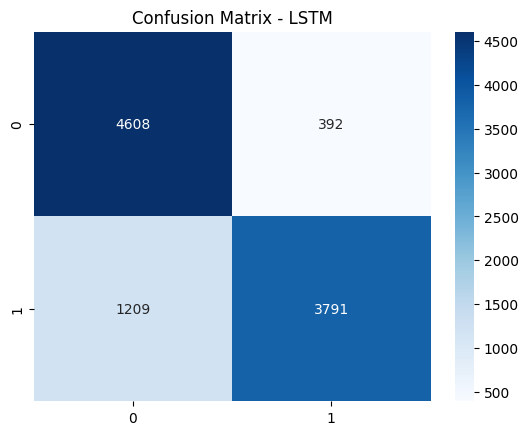

              precision    recall  f1-score   support

           0       0.79      0.92      0.85      5000
           1       0.91      0.76      0.83      5000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



In [10]:
#B22DCCN476 - Đỗ Ngọc Lâm

test_loss_lstm, test_acc_lstm = lstm_model.evaluate(X_test_seq, y_test, verbose=0)
print(test_loss_lstm, test_acc_lstm)

y_pred_lstm = (lstm_model.predict(X_test_seq) >= 0.5).astype(int).reshape(-1)

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - LSTM")
plt.show()

print(classification_report(y_test, y_pred_lstm))


***Cell 11: Build GRU Model***

In [11]:
#B22DCCN476 - Đỗ Ngọc Lâm


def build_gru():
    model = models.Sequential([
        layers.Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        layers.SpatialDropout1D(0.2),
        layers.GRU(128),
        layers.Dropout(0.5),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

gru_model = build_gru()
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_1                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

***Cell 12: Train GRU***

In [12]:
#B22DCCN476 - Đỗ Ngọc Lâm

history_gru = gru_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 62s 221ms/step - accuracy: 0.5144 - loss: 0.6940 - val_accuracy: 0.5008 - val_loss: 0.6979
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 58s 211ms/step - accuracy: 0.5471 - loss: 0.6853 - val_accuracy: 0.5392 - val_loss: 0.6861
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 58s 212ms/step - accuracy: 0.6384 - loss: 0.5922 - val_accuracy: 0.8344 - val_loss: 0.3954
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 59s 214ms/step - accuracy: 0.8938 - loss: 0.2861 - val_accuracy: 0.8840 - val_loss: 0.3307
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 58s 211ms/step - accuracy: 0.9441 - loss: 0.1670 - val_accuracy: 0.8728 - val_loss: 0.4028
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 58s 211ms/step - accuracy: 0.9680 - loss: 0.1027 - val_accuracy: 0.8726 - val_loss: 0.4387
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 57s 209ms/step - accuracy: 0.9813 - loss: 0.0625 - val_accuracy: 0.8600 - val_loss: 0.5304
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 57s 210ms/step - accuracy: 0.9887 - loss: 0

***Cell 13: Plot training curves (GRU)***

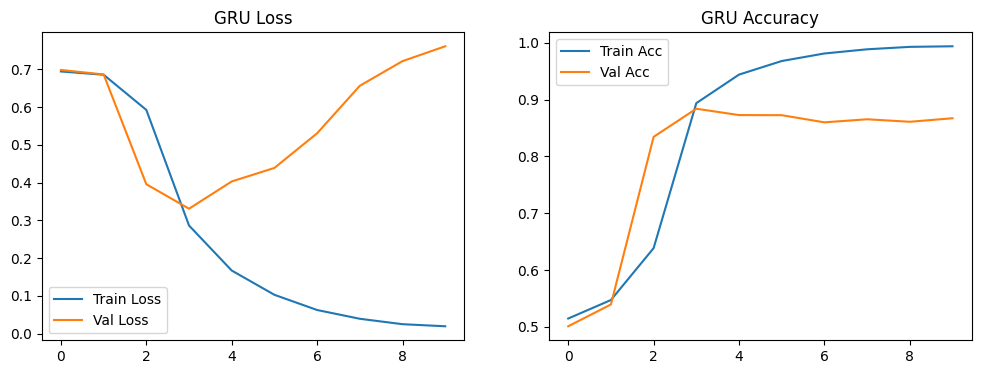

In [14]:
#B22DCCN476 - Đỗ Ngọc Lâm

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_gru.history["loss"], label="Train Loss")
plt.plot(history_gru.history["val_loss"], label="Val Loss")
plt.title("GRU Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_gru.history["accuracy"], label="Train Acc")
plt.plot(history_gru.history["val_accuracy"], label="Val Acc")
plt.title("GRU Accuracy")
plt.legend()

plt.show()


***Cell 14: Test GRU***

0.7847914695739746 0.8641999959945679
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


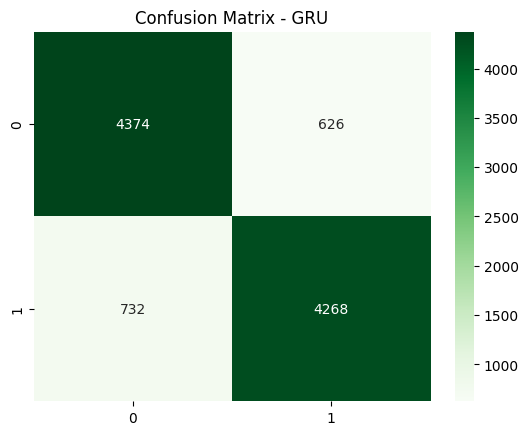

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      5000
           1       0.87      0.85      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [15]:
#B22DCCN476 - Đỗ Ngọc Lâm

test_loss_gru, test_acc_gru = gru_model.evaluate(X_test_seq, y_test, verbose=0)
print(test_loss_gru, test_acc_gru)

y_pred_gru = (gru_model.predict(X_test_seq) >= 0.5).astype(int).reshape(-1)

cm_gru = confusion_matrix(y_test, y_pred_gru)

sns.heatmap(cm_gru, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - GRU")
plt.show()

print(classification_report(y_test, y_pred_gru))


***Cell 15: Compare LSTM vs GRU***

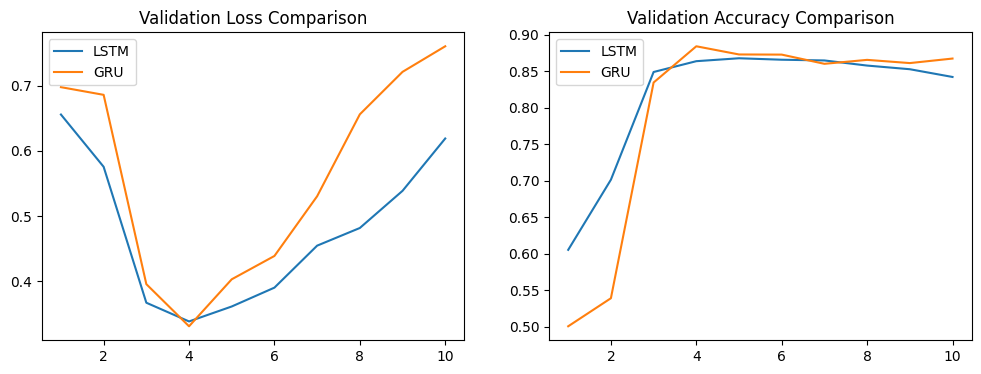

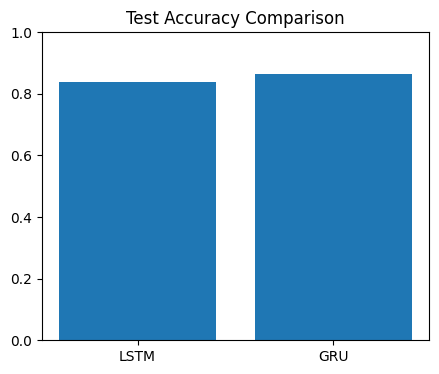

LSTM Test Acc: 0.8399
GRU  Test Acc: 0.8642


In [16]:
#B22DCCN476 - Đỗ Ngọc Lâm

epochs_range = range(1, EPOCHS+1)

plt.figure(figsize=(12,4))

# Compare Validation Loss
plt.subplot(1,2,1)
plt.plot(epochs_range, history_lstm.history["val_loss"], label="LSTM")
plt.plot(epochs_range, history_gru.history["val_loss"], label="GRU")
plt.title("Validation Loss Comparison")
plt.legend()

# Compare Validation Accuracy
plt.subplot(1,2,2)
plt.plot(epochs_range, history_lstm.history["val_accuracy"], label="LSTM")
plt.plot(epochs_range, history_gru.history["val_accuracy"], label="GRU")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.show()

# Bar chart test accuracy
plt.figure(figsize=(5,4))
plt.bar(["LSTM","GRU"], [test_acc_lstm, test_acc_gru])
plt.ylim(0.0, 1.0)
plt.title("Test Accuracy Comparison")
plt.show()

print(f"LSTM Test Acc: {test_acc_lstm:.4f}")
print(f"GRU  Test Acc: {test_acc_gru:.4f}")
